# World Population & Poverty Trends

An exploration of how population growth, fertility, life expectancy, child mortality, and extreme poverty have changed globally and within individual countries, using data from [Gapminder.org](http://gapminder.org).

Gapminder aggregates statistics from many sources — the UN, World Bank, and others — into a single comparable dataset called the *Systema Globalis*. This analysis is dedicated to [Hans Rosling](https://en.wikipedia.org/wiki/Hans_Rosling), the physician and statistician who championed using data like this to build a more fact-based understanding of the world.


In [ ]:
# Setup
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


## Part 1: Global Population Growth


The global population reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The UN Population Division expects growth to continue but slow considerably, possibly stabilizing around 11 billion by 2100 — though slower or more extreme scenarios aren't ruled out.

To understand *why* population growth has been slowing, I looked first at a single country in depth — Poland — before checking whether the same patterns hold worldwide.

### Poland

Poland is a useful case study: it was re-created as a democratic republic in 1919, invaded and divided during WWII, rebuilt under a communist government from 1945, and became a democracy again in 1989. Its population history reflects all of that upheaval.

In [ ]:
population = Table.read_table('population.csv').where("time", are.below(2021))
population.show(3)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


First, I pulled Poland's total population for every year from 1900 to 2020 (Poland's `geo` code, `pol`, follows the ISO Alpha-3 standard used throughout this dataset).

In [ ]:
p_pop = population.where('geo', 'pol').where('time', are.between_or_equal_to(1900, 2020)).drop('geo')
p_pop

time,population_total
1900,24340168
1901,24517983
1902,24694172
1903,24868705
1904,25044468
1905,25221471
1906,25399722
1907,25579229
1908,25760003
1909,25848341


Sampling every five years makes the long-run trend easier to see. Following the devastation of both World Wars, Poland's population climbed steadily from 1950 to 2000 before leveling off.

In [ ]:
p_pop.set_format('population_total', NumberFormatter)

fives = np.arange(1900, 2021, 5) # 1900, 1905, 1910, ...
p_five = p_pop.sort('time').where('time', are.contained_in(fives))
p_five.show(3)

time,population_total
1900,"24,340,168"
1905,"25,221,471"
1910,"25,844,639"


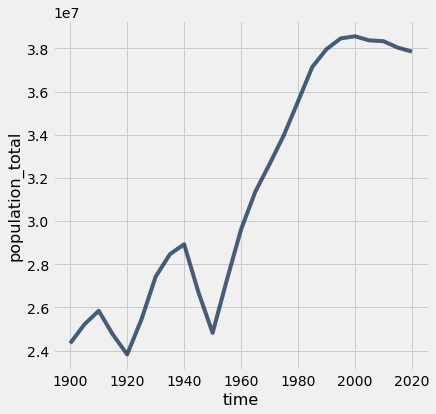

In [ ]:
p_five.plot(0, 1)

To quantify that leveling-off, I computed the annual growth rate for each five-year window (using the standard compound growth formula). The rate has been declining fairly steadily since 1950.

In [ ]:
initial = p_five.where('time', are.between_or_equal_to(1900, 2015)).column('population_total')
changed = p_five.where('time', are.between_or_equal_to(1905, 2020)).column('population_total')

p_1900_through_2015 = p_five.where('time', are.below_or_equal_to(2015))
p_five_growth = p_1900_through_2015.with_column('annual_growth', (changed / initial) ** 0.2 - 1)
p_five_growth.set_format('annual_growth', PercentFormatter)


time,population_total,annual_growth
1900,"24,340,168",0.71%
1905,"25,221,471",0.49%
1910,"25,844,639",-0.87%
1915,"24,739,041",-0.75%
1920,"23,827,906",1.32%
1925,"25,439,942",1.52%
1930,"27,427,399",0.75%
1935,"28,465,230",0.32%
1940,"28,927,566",-1.58%
1945,"26,713,772",-1.46%


In [ ]:
# Annual growth rates in Poland since 1950
p_five_growth.where('time', are.above_or_equal_to(1950)).show()


time,population_total,annual_growth
1950,"24,824,007",1.90%
1955,"27,269,742",1.66%
1960,"29,614,201",1.15%
1965,"31,360,903",0.80%
1970,"32,639,262",0.80%
1975,"33,970,730",0.91%
1980,"35,539,723",0.88%
1985,"37,133,860",0.44%
1990,"37,960,193",0.26%
1995,"38,458,642",0.05%


So — what's actually driving that decline? I loaded three more indicators to investigate: **life expectancy at birth** (a snapshot measure of how long people would live if a given year's mortality conditions persisted for a lifetime), **child mortality** (deaths per 1,000 children under 5), and **total fertility rate** (average children per woman over her lifetime, at current age-specific birth rates).

In [ ]:
life_expectancy = Table.read_table('life_expectancy.csv').where('time', are.below(2021))
child_mortality = Table.read_table('child_mortality.csv').relabel(2, 'child_mortality_under_5_per_1000_born').where('time', are.below(2021))
fertility = Table.read_table('fertility.csv').where('time', are.below(2021))

In [ ]:
life_expectancy.show(3)

geo,time,life_expectancy_years
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19


In [ ]:
child_mortality.show(3)

geo,time,child_mortality_under_5_per_1000_born
afg,1800,468.58
afg,1801,468.58
afg,1802,468.58


In [ ]:
fertility.show(3)

geo,time,children_per_woman_total_fertility
abw,1800,5.64
abw,1801,5.64
abw,1802,5.64


**Is population growth slowing because people aren't living as long?**

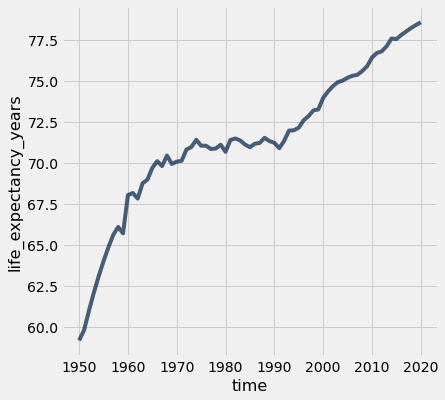

In [ ]:
pol_life_expectancy = life_expectancy.where('geo', 'pol')
pol_life_expectancy.where('time', are.above_or_equal_to(1950)).plot('time', 'life_expectancy_years')


No — if anything, the opposite. Life expectancy in Poland has been *increasing* since 1950, meaning people are living longer, not shorter, lives. That alone can't directly explain a *declining* growth rate — to establish real causation we'd need more than a time trend. But it does hint at a plausible mechanism: as people live longer, adults increasingly find themselves caring for aging relatives, which may factor into decisions to have fewer children.

**What about fertility?**

In [ ]:
def fertility_over_time(country_code, start):
    """Create a two-column table describing a country's total fertility rate each year."""
    return (fertility
            .where('geo', country_code)
            .where('time', are.above_or_equal_to(start))
            .drop('geo')
            .relabeled('time', 'Year')
            .relabeled('children_per_woman_total_fertility', 'Children per woman'))

poland_code = 'pol'
fertility_over_time(poland_code, 1950)


Year,Children per woman
1950,3.6
1951,3.62
1952,3.64
1953,3.65
1954,3.64
1955,3.6
1956,3.55
1957,3.47
1958,3.37
1959,3.25


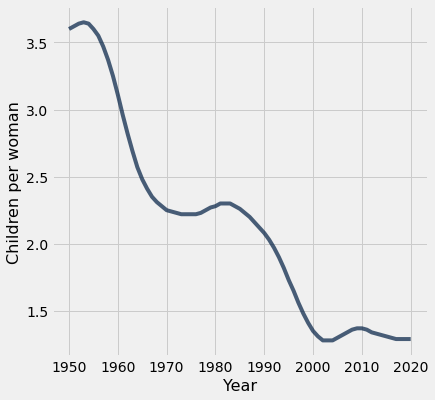

In [ ]:
fertility_over_time(poland_code, 1950).plot(0, 1)


This is a much more direct story. Fertility in Poland has fallen sharply and steadily since 1950 — from roughly 3-4 children per woman down to well under 2. Since population growth depends directly on how many children are born, a shrinking fertility rate translates almost mechanically into a shrinking growth rate, especially once fertility drops near or below the replacement level.

It's a well-documented pattern that falling fertility tends to track falling child mortality — as families gain more confidence that their children will survive to adulthood, they tend to have fewer of them. Does that hold for Poland?

In [ ]:
pol_fertility = fertility_over_time(poland_code, 1950)
pol_child_mortality = (child_mortality
                       .where('time', are.above_or_equal_to(1950))
                       .where('geo', 'pol')
                       .column('child_mortality_under_5_per_1000_born'))
poland_since_1950 = pol_fertility.with_column('Child deaths per 1000 born', pol_child_mortality)
poland_since_1950


Year,Children per woman,Child deaths per 1000 born
1950,3.6,164.08
1951,3.62,177.18
1952,3.64,140.16
1953,3.65,127.65
1954,3.64,118.9
1955,3.6,110.38
1956,3.55,94.19
1957,3.47,86.72
1958,3.37,81.28
1959,3.25,72.1


The scatter plot below colors each year from dark blue (1950s) to light blue (2010s), tracing the relationship over time.

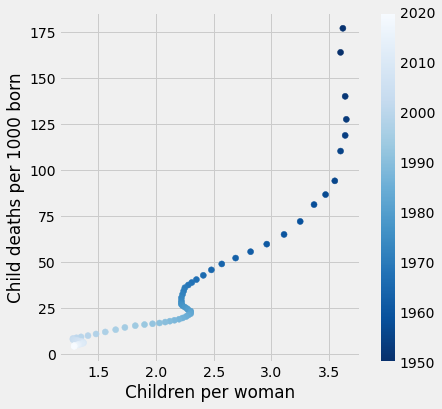

In [ ]:
x_births = poland_since_1950.column("Children per woman")
y_deaths = poland_since_1950.column("Child deaths per 1000 born")
time_colors = poland_since_1950.column("Year")

plots.figure(figsize=(6,6))
plots.scatter(x_births, y_deaths, c=time_colors, cmap="Blues_r")
plots.colorbar()                  
plots.xlabel("Children per woman")
plots.ylabel("Child deaths per 1000 born");

Yes — clearly. As child mortality fell, fertility fell right along with it. This is only an association (a scatter plot can't establish causation on its own), but it lines up with the broader pattern: as more children survive, families need fewer births to reach their desired family size.

### Beyond Poland: does the same pattern hold worldwide?

The changes observed in Poland — rising life expectancy, falling child mortality, and plummeting fertility despite the longevity gains — show up in most countries, except during extended war, famine, or social upheaval. Comparing the distribution of fertility rates across all 201 countries in 1962 versus 2010 makes the global shift obvious:

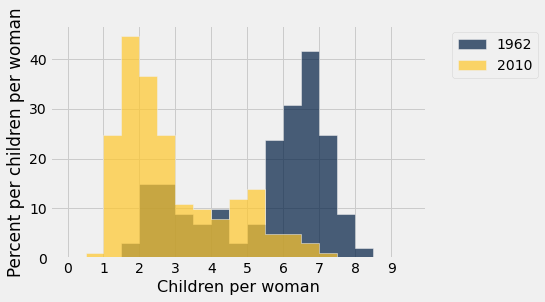

In [ ]:
Table().with_columns(
    '1962', fertility.where('time', 1962).column(2),
    '2010', fertility.where('time', 2010).column(2)
).hist(bins=np.arange(0, 10, 0.5), unit='child per woman')
_ = plots.xlabel('Children per woman')
_ = plots.ylabel('Percent per children per woman')
_ = plots.xticks(np.arange(10))

The shift is dramatic: in 1962 the bulk of countries clustered around 5-8 children per woman; by 2010 that mass had shifted down to roughly 1.5-3. More countries had crossed below a fertility rate of 3 by 2010 than were above it in 1962 — a near-total reversal of the global distribution in under 50 years.

Zooming out to total world population over the long run:

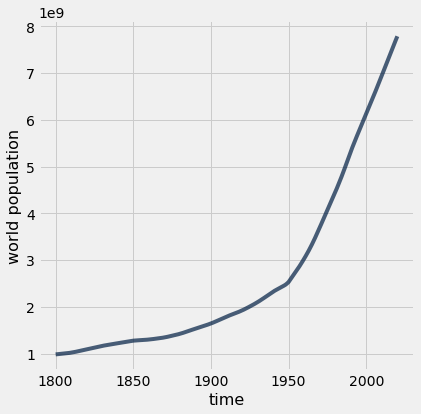

In [ ]:
new_pop = population.where('time', are.between_or_equal_to(1800, 2020))
world_pop = new_pop.group('time', sum).relabeled('population_total sum', 'world population')
world_pop.plot('time', 'world population')


To dig into regional patterns without the computational cost of tracking all ~200 countries, I restricted later analysis to the 50 most populous countries as of 2020 — which still account for the large majority of the world's population — and built a helper that joins population, fertility, and child mortality for any given year.

In [ ]:
# Restrict to the 50 most populous countries in 2020 to keep later computations fast.
big_50 = (population
          .where('time', are.equal_to(2020))
          .sort("population_total", descending=True)
          .take(np.arange(50))
          .column('geo'))
population_of_big_50 = population.where('time', are.above(1959)).where('geo', are.contained_in(big_50))

def stats_for_year(year):
    """Return a table of population, fertility, and child mortality for each of the big 50
    countries in a given year."""
    p = population_of_big_50.where('time', are.equal_to(year)).drop('time')
    f = fertility.where('time', are.equal_to(year)).drop('time')
    c = child_mortality.where('time', are.equal_to(year)).drop('time')
    return p.join('geo', f).join('geo', c)

stats_for_year(2019)


geo,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
afg,38041757,4.18,60.15
ago,31825299,5.48,74.52
arg,44780675,2.25,9.66
bgd,163046173,2.02,28.9
bra,211049519,1.69,13.9
can,37411038,1.56,4.94
chn,1433783692,1.64,8.34
cod,86790568,5.82,86.24
col,50339443,1.8,13.84
deu,83517046,1.48,3.46


Aggregating that by decade shows the total population of these 50 countries climbing steadily:

In [ ]:
def pop_for_year(year):
    """Total population across the big-50 countries for a given year."""
    return sum(stats_for_year(year).column('population_total'))

pop_for_year(2019)


6698479985

In [ ]:
decades = Table().with_column('decade', np.arange(1960, 2021, 10))
pop_by_decade = decades.with_column('population', decades.apply(pop_for_year))
pop_by_decade.set_format(1, NumberFormatter)


decade,population
1960,"2,635,123,897"
1970,"3,221,457,416"
1980,"3,890,044,418"
1990,"4,656,339,803"
2000,"5,377,062,169"
2010,"6,064,674,132"
2020,"6,765,161,289"


The `countries` table classifies each country into a world region, which is useful for seeing whether these 50 largest countries are concentrated in particular parts of the world.

In [ ]:
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
countries.select('country', 'name', 'world_6region')


country,name,world_6region
afg,Afghanistan,south_asia
ago,Angola,sub_saharan_africa
alb,Albania,europe_central_asia
and,Andorra,europe_central_asia
are,United Arab Emirates,middle_east_north_africa
arg,Argentina,america
arm,Armenia,europe_central_asia
atg,Antigua and Barbuda,america
aus,Australia,east_asia_pacific
aut,Austria,europe_central_asia


In [ ]:
stats_for_2020 = stats_for_year(2020).group('geo')
region_counts = (stats_for_2020
                 .join('geo', countries, 'country')
                 .select('world_6region')
                 .group('world_6region')
                 .relabeled('world_6region', 'region'))
region_counts


region,count
america,8
east_asia_pacific,9
europe_central_asia,10
middle_east_north_africa,7
south_asia,5
sub_saharan_africa,11


Putting fertility, child mortality, population (dot size), and region (color) all on one chart makes the global pattern vivid. Here's 1960:

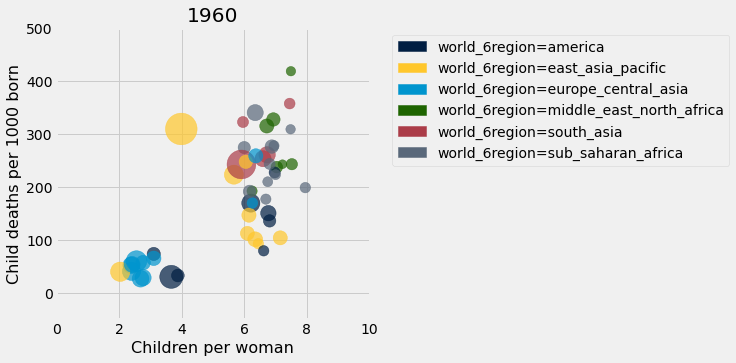

In [ ]:
from functools import lru_cache as cache

@cache(None)
def stats_relabeled(year):
    """Relabeled, cached version of stats_for_year (avoids recomputing per repeated call)."""
    return stats_for_year(year).relabel(2, 'Children per woman').relabel(3, 'Child deaths per 1000 born')

def fertility_vs_child_mortality(year):
    """Color scatter diagram comparing child mortality and fertility, sized by population
    and colored by region."""
    with_region = stats_relabeled(year).join('geo', countries.select('country', 'world_6region'), 'country')
    with_region.scatter(2, 3, sizes=1, group=4, s=500)
    plots.xlim(0, 10)
    plots.ylim(-50, 500)
    plots.title(year)
    plots.show()

fertility_vs_child_mortality(1960)


In 1960, there's a clear positive association between fertility and child mortality — countries with higher child death rates tended to also have higher birth rates. Most countries sat well above a fertility rate of 5, and the two most populous countries at the time (sized largest) also had among the highest child mortality rates.

The cell below is interactive: dragging the slider steps through each year from 1960 to 2020, showing how dramatically the picture changes — the gap between the Global North and Global South narrows sharply over time as fertility and child mortality fall together nearly everywhere. (This shift in fertility is the main reason global population is expected to grow more slowly in the 21st century than it did in the 19th and 20th — driven by cultural change, better odds of children surviving to adulthood, and greater access to family planning.)

In [ ]:
_ = widgets.interact(fertility_vs_child_mortality,
                     year=widgets.IntSlider(min=1960, max=2020, value=1960))


interactive(children=(IntSlider(value=1960, description='year', max=2020, min=1960), Output()), _dom_classes=(…

One last note on this section: population and fertility statistics can't be read as purely abstract numbers. Studying them means engaging with real people's lives, and this kind of data has historically been entangled with fraught political currents — population control, control over women's reproductive choices, and anxieties about shifting demographics between groups. Treating this as "just data" risks reproducing those patterns unthinkingly, so it's worth naming that tension directly rather than pretending the numbers are neutral.

## Part 2: Global Poverty


In 1800, roughly 85% of the world's ~1 billion people lived in extreme poverty — defined by the UN as severe deprivation of basic needs like food, clean water, sanitation, health care, shelter, and education. At the time this dataset was compiled, extreme poverty was commonly defined as living on less than \$1.25/day. By 2018 that global rate had fallen to roughly 9% — still well over 600 million people. The UN's Sustainable Development Goals set an explicit target: eradicate extreme poverty entirely by 2030.

The causes of poverty are tangled up with global history — colonialism, health care access, economic structure, and social inequality all play a role, and vary enormously by country. This section looks at a few angles on the current picture and how it's shifted over time.

In [ ]:
# Setup for this section
import numpy as np
from datascience import *

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


The `poverty` table only has a measurement for each country in the specific years a survey was conducted, unlike `population`, which has a value for every year.

In [ ]:
population = Table.read_table('population.csv')
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
poverty = Table.read_table('poverty.csv')
poverty.show(3)

geo,time,extreme_poverty_percent_people_below_125_a_day
alb,1996,0.2
alb,2002,0.73
alb,2004,0.53


For each country, I took its *most recent* available poverty rate — whatever year that happened to be measured in.

In [ ]:
def first(values):
    return values.item(0)

latest_poverty = poverty.sort('time', descending=True).group('geo', first)
latest_poverty = latest_poverty.relabeled(0, 'geo').relabeled(1, 'time').relabeled(2, 'poverty_percent')
latest_poverty


geo,time,poverty_percent
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


Converting those percentages into absolute numbers of people (using each country's 2010 population) makes the scale of the problem concrete rather than abstract.

In [ ]:
pop_2010 = population.where('time', are.equal_to(2010))
poverty_and_pop = latest_poverty.join('geo', pop_2010).select('geo', 'poverty_percent', 'population_total')
poverty_decimal = poverty_and_pop.column('poverty_percent') / 100
poverty_total = np.round(poverty_decimal * poverty_and_pop.column('population_total'))
recent_poverty_total = poverty_and_pop.with_column('poverty_total', poverty_total)
recent_poverty_total


geo,poverty_percent,population_total,poverty_total
ago,43.37,23356247,1.01296e+07
alb,0.46,2948029,13561
arg,1.41,40895751,576630
arm,1.75,2877314,50353
aus,1.36,22154687,301304
aut,0.34,8409945,28594
aze,0.31,9032465,28001
bdi,81.32,8675606,7.055e+06
bel,0.5,10938735,54694
ben,51.61,9199254,4.74774e+06


Summed across every country with data, and compared against total 2010 world population:

In [ ]:
pop_2010 = population.where('time', are.equal_to(2010))
poverty_percent = sum(recent_poverty_total.column('poverty_total')) / sum(pop_2010.column('population_total')) * 100
poverty_percent


14.248865303997139

That comes out above the 2018 global estimate of ~9% — expected, since many of the country-level poverty rates feeding into this number are older than 2018, from a period when the rate was still higher.

Mapping this out geographically — circle area proportional to the number of people in extreme poverty — shows where the burden is concentrated.

In [ ]:
poverty_map = (countries
               .join('country', recent_poverty_total, 'geo')
               .select('latitude', 'longitude', 'name', 'world_4region', 'poverty_total')
               .relabeled('world_4region', 'region'))
poverty_map


latitude,longitude,name,region,poverty_total
-12.5,18.5,Angola,africa,1.01296e+07
41,20,Albania,europe,13561
-34,-64,Argentina,americas,576630
40.25,45,Armenia,europe,50353
-25,135,Australia,asia,301304
47.3333,13.3333,Austria,europe,28594
40.5,47.5,Azerbaijan,europe,28001
-3.5,30,Burundi,africa,7.055e+06
50.75,4.5,Belgium,europe,54694
9.5,2.25,Benin,africa,4.74774e+06


In [ ]:
colors = {'africa': 'blue', 'europe': 'black', 'asia': 'red', 'americas': 'green'}
scaled = poverty_map.with_columns(
    'labels', poverty_map.column('name'),
    'colors', poverty_map.apply(colors.get, 'region'),
    'areas', 1e-4 * poverty_map.column('poverty_total')
).drop('name', 'region', 'poverty_total')

Circle.map_table(scaled)


People lived in extreme poverty across every region in 2010 — including more than 5 million in the United States — but the largest absolute numbers were concentrated in Asia and Africa.

In [ ]:
largest = poverty_map.sort('poverty_total', descending=True).take(np.arange(0, 10)).select('name', 'poverty_total')
largest.set_format('poverty_total', NumberFormatter)


name,poverty_total
India,"291,660,639.00"
Nigeria,"98,319,537.00"
China,"85,687,544.00"
Bangladesh,"63,826,375.00"
"Congo, Dem. Rep.","56,635,412.00"
Indonesia,"39,177,145.00"
Ethiopia,"32,242,742.00"
Pakistan,"22,858,700.00"
Tanzania,"19,281,872.00"
Madagascar,"18,543,643.00"


The *percentage* of a country living in poverty and the *absolute number* of people it represents are both important, but tell different stories — the absolute number is what actually determines how much aid or infrastructure a country needs. To track how that absolute number has moved over time for a given country, I wrote a function that joins that country's poverty-rate history against its population history and multiplies the two together year by year, then plots the resulting trend.

In [ ]:
def poverty_timeline(country):
    """Plot the number of people living in extreme poverty in a country over time."""
    geo = countries.where('name', country).column('country').item(0)
    country_poverty = poverty.where('geo', geo)
    country_pop = population.where('geo', geo)
    joined = country_poverty.join('time', country_pop).drop('geo_2')
    people_in_poverty = joined.column('extreme_poverty_percent_people_below_125_a_day') * joined.column('population_total')
    result = joined.with_column('people_living_in_poverty', people_in_poverty)
    result.plot('time', 'people_living_in_poverty')
    plots.title(country)
    plots.ylim(bottom=0)
    plots.show()


A few countries with very different trajectories:

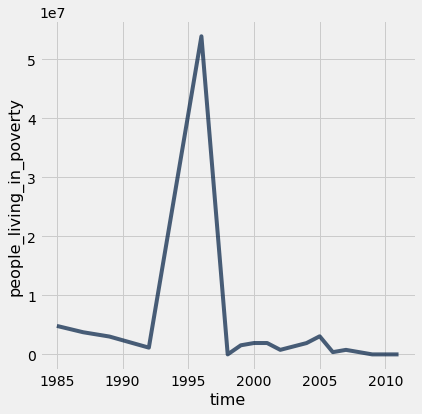

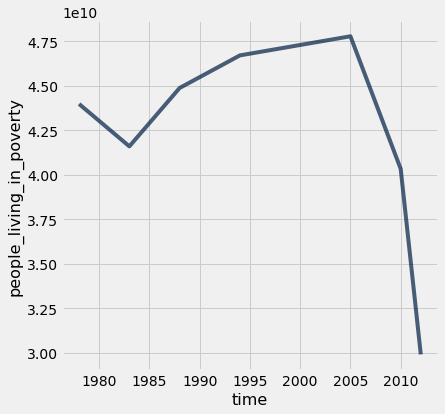

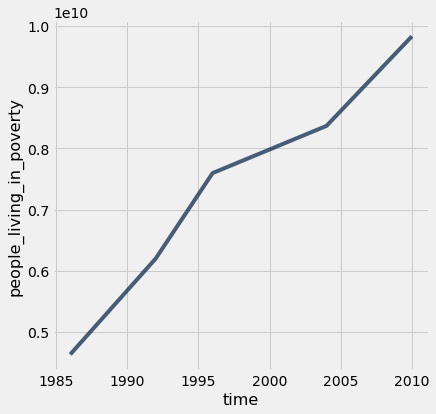

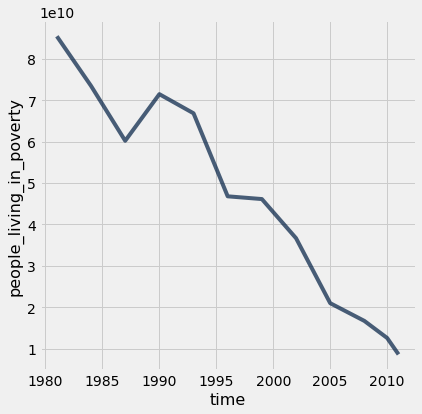

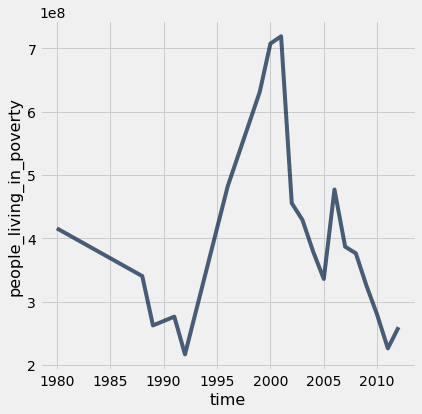

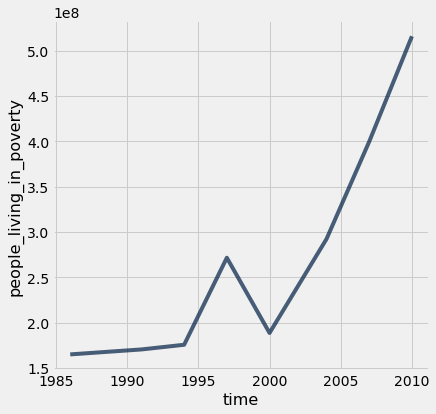

In [ ]:
poverty_timeline('Poland')
poverty_timeline('India')
poverty_timeline('Nigeria')
poverty_timeline('China')
poverty_timeline('Colombia')
poverty_timeline('United States')


The number of people in extreme poverty *increased* in some countries — notably Nigeria and the United States — but massive decreases in China and India dominate the overall trend: extreme poverty has been falling worldwide, both as a percentage and in absolute numbers.

Below is an interactive version — pick any country from the dropdown to see its own timeline.

In [ ]:
all_countries = poverty_map.column('name')
_ = widgets.interact(poverty_timeline, country=list(all_countries))


interactive(children=(Dropdown(description='country', options=('Angola', 'Albania', 'Argentina', 'Armenia', 'A…

---

### Closing thoughts

Across both population and poverty, the same underlying story shows up from different angles: nearly every country has followed a broadly similar arc as it develops — child mortality falls, life expectancy rises, fertility drops, and (with a lag) poverty declines. The pace and timing differ enormously by country and region, and the story isn't uniformly positive — some countries have seen poverty rise, and the political history behind these numbers is not neutral. But the aggregate global trend, visible across a century of data, is a real and significant decline in both extreme poverty and unchecked population growth.